In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer

In [2]:
df = pd.read_csv('spam.csv',  encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.columns


Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

# Data Cleaning and EDA

In [5]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace = True)

In [6]:
df.columns

Index(['v1', 'v2'], dtype='object')

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.rename(columns= {'v1':'target','v2':'text'}, inplace = True)
df.sample(5)

,target,text
555,ham,O. Well uv causes mutations. Sunscreen is like...
5057,ham,"Geeeee ... Your internet is really bad today, ..."
1771,ham,Watching tv now. I got new job :)
5295,ham,Alex says he's not ok with you not being ok wi...
4422,ham,alright. Thanks for the advice. Enjoy your nig...


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder() # object creation
df['target'] = encoder.fit_transform(df['target'])
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# checking missing values means null values 

df.isnull().sum()

target    0
text      0
dtype: int64

In [11]:
df.duplicated().sum()

403

In [12]:
df = df.drop_duplicates(keep = 'first')
df.duplicated().sum()

0

In [13]:
df.shape

(5169, 2)

In [14]:
df['target'].value_counts() # to check data distribution

target
0    4516
1     653
Name: count, dtype: int64

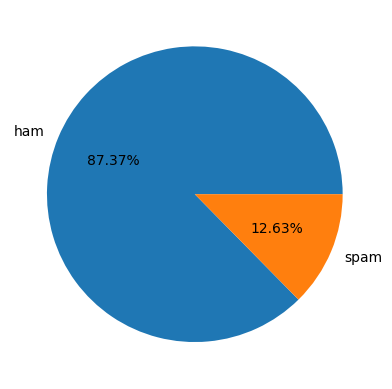

In [15]:
plt.pie(df['target'].value_counts(), labels = ['ham','spam'], autopct = '%0.2f%%' )
plt.show() # data is imbalanced here we can see

In [16]:
!pip install nltk


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import nltk

In [18]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saroj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
df['num_characters'] = df['text'].apply(len)
print(df['num_characters'])

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 5169, dtype: int64


In [20]:
# counting number of words 
#df['text'].apply(lambda x : nltk.word_tokenize(x))

df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

df['num_words']

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: num_words, Length: 5169, dtype: int64

In [21]:
#df['text'].apply(lambda x : nltk.sent_tokenize(x))

df['num_sentence'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df['num_sentence']



0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: num_sentence, Length: 5169, dtype: int64

In [22]:
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [23]:
df.describe()

,target,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [24]:
df[df['target'] == 0][['num_characters','num_words', 'num_sentence']].describe() # hamp

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
df[df['target'] == 1][['num_characters','num_words', 'num_sentence']].describe() # spam

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

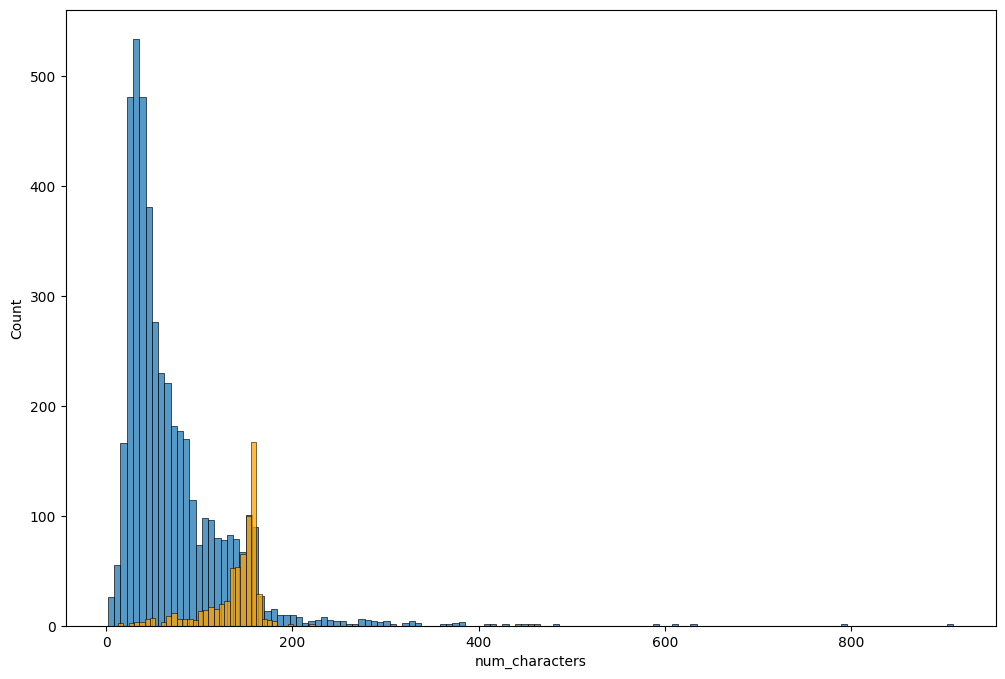

In [26]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'], color='orange')


<Axes: xlabel='num_sentence', ylabel='Count'>

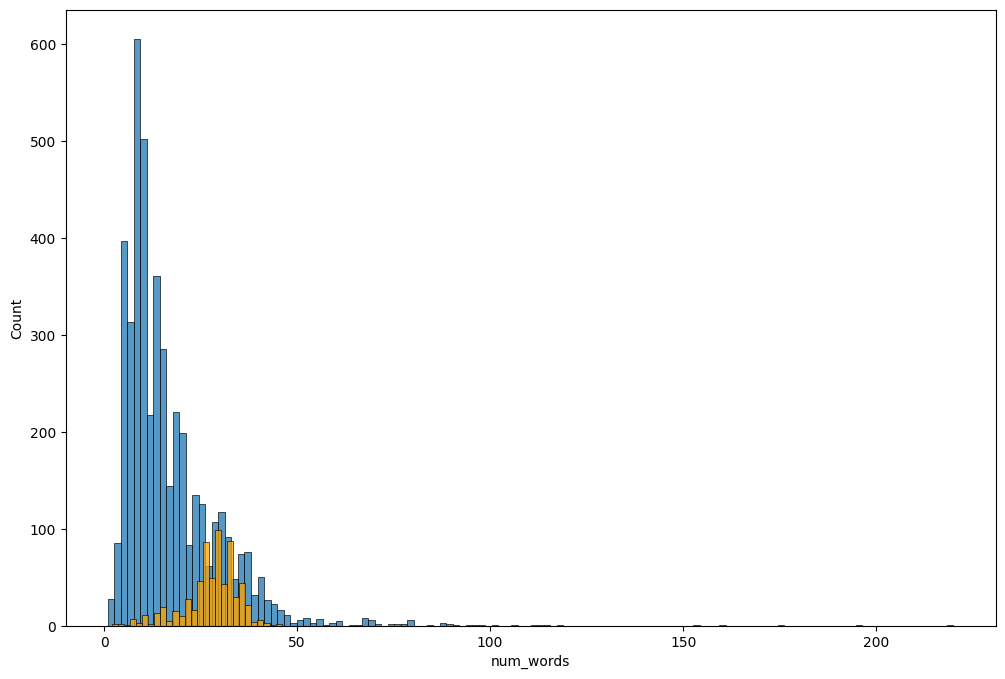

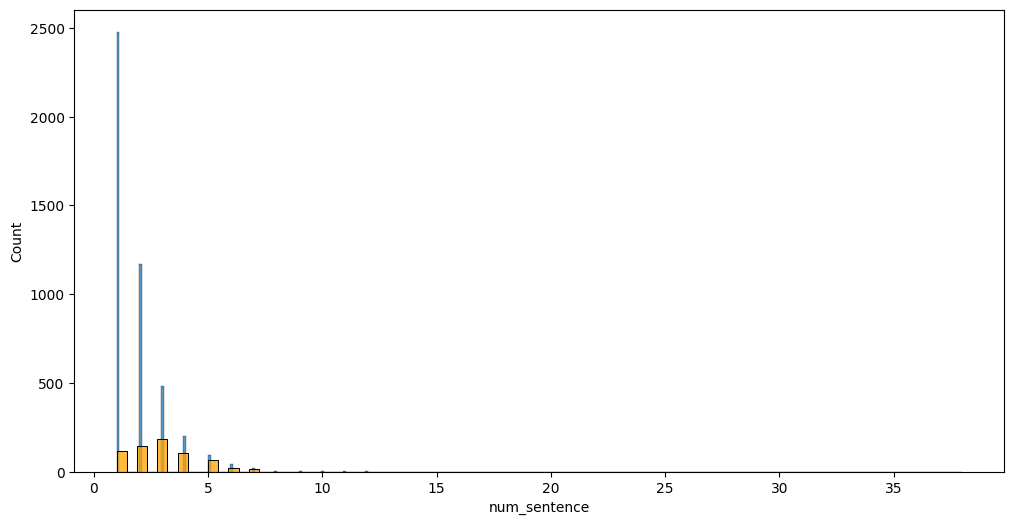

In [27]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'], color='orange')

plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_sentence'])
sns.histplot(df[df['target']==1]['num_sentence'], color='orange')


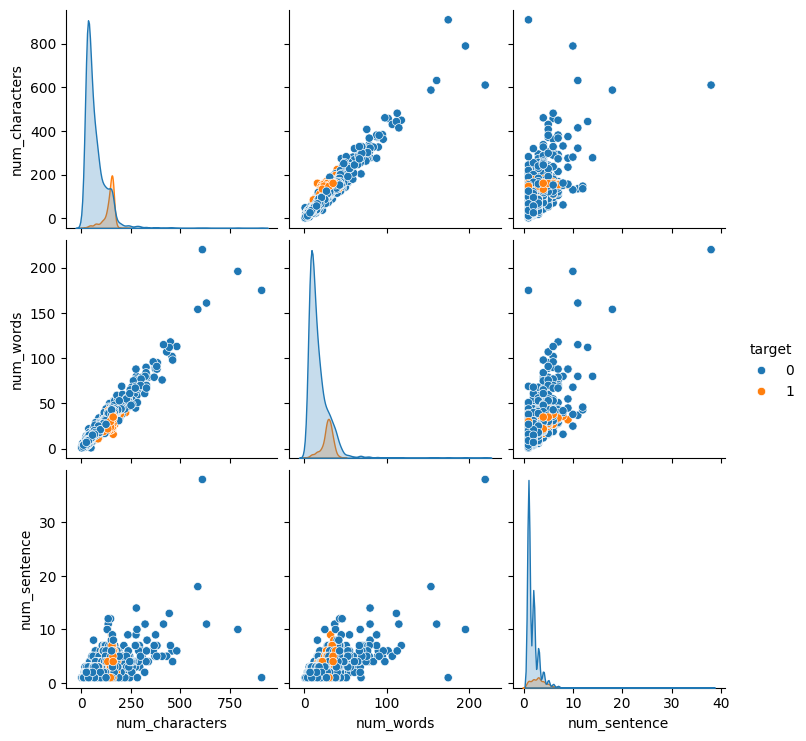

In [28]:
sns.pairplot(df,hue='target')

In [29]:
#sns.heatmap(df.corr(),annot=True)

# Data preprocessing
Lower case
Tokenization
Removing special characters
Removing stop words and punctuation
stemming

In [30]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [31]:
def data_prepeocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    temp = []

    for i in text:
        if i.isalnum():
            temp.append(i)
    
    text = temp[:]
    temp.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation :
            temp.append(i)
    
    text = temp[:]
    temp.clear()

    for i in text:
        temp.append(ps.stem(i))
        

    return " ".join(temp)


In [32]:
#data_prepeocessing ('Hollo i am saroj')

In [33]:
data_prepeocessing ('Hollo i am saroj and i love dancing.')

'hollo saroj love danc'

In [34]:
# from nltk.stem.porter import PorterStemmer
# ps = PorterStemmer()
# ps.stem('dancing')

In [35]:
# now will add that the transform into a new column

df['transform_text'] = df['text'].apply(data_prepeocessing)
df.head()


,target,text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [36]:
#!pip install wordcloud

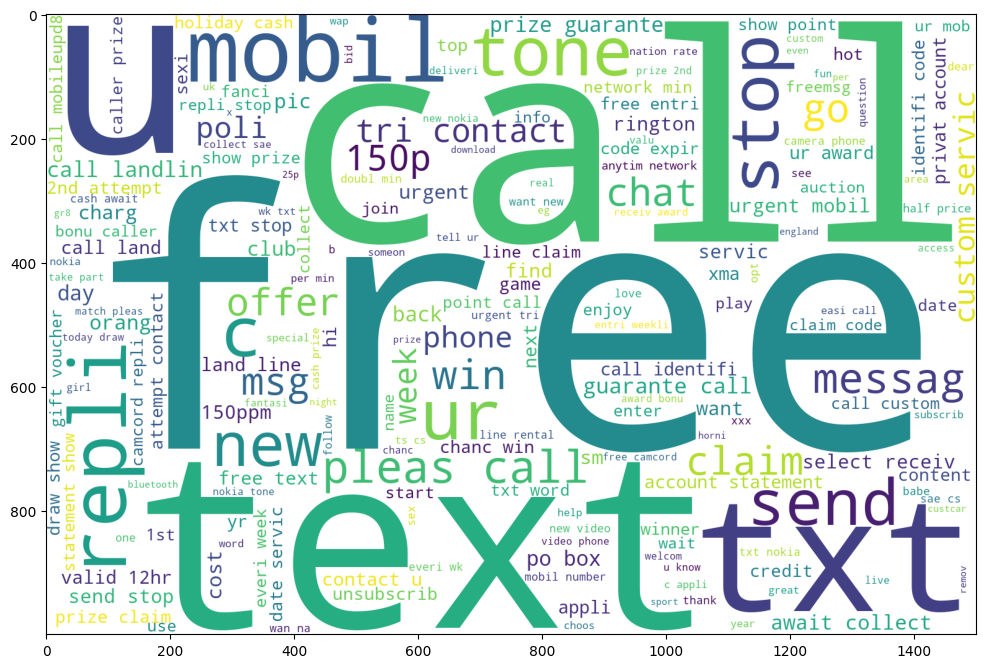

In [37]:
from wordcloud import WordCloud
wc = WordCloud(width = 1500, height = 1000, min_font_size=10, background_color = 'white')

spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep = " "))
plt.figure(figsize=(12,16))
plt.imshow(spam_wc)


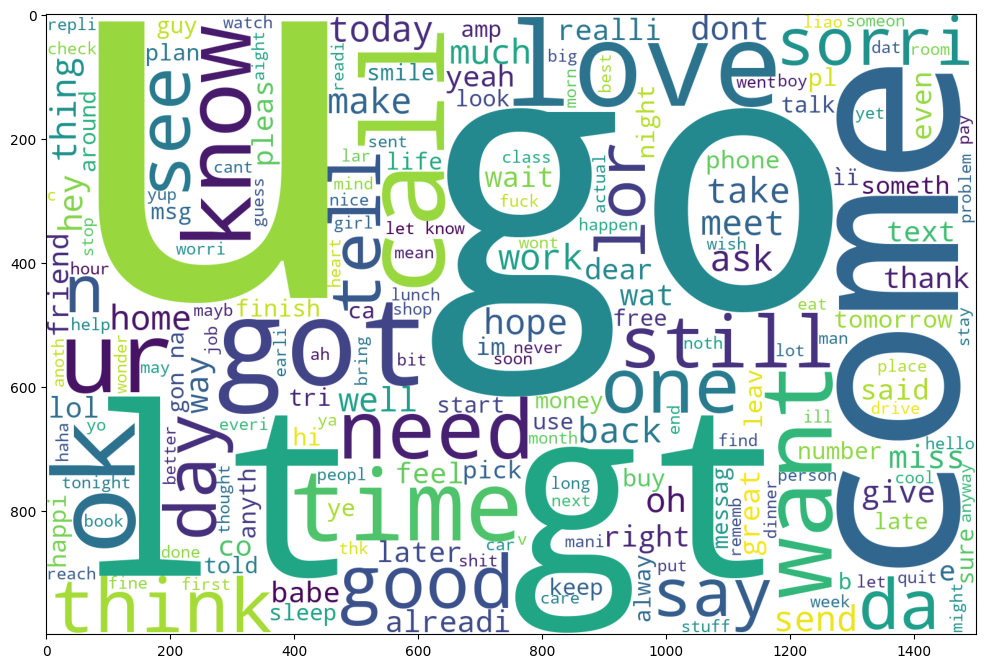

In [38]:
ham_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep = " "))
plt.figure(figsize=(12,16))
plt.imshow(ham_wc)

In [39]:
#30 Most frequent words in spam

spam_Most_freq_word = []
for msg in df[df['target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        spam_Most_freq_word.append(word)

In [40]:
len(spam_Most_freq_word)

9939

In [41]:
from collections import Counter 
#Counter(spam_Most_freq_word) # it will count all the variable frequency
Counter(spam_Most_freq_word).most_common(30) # most common 30 words comes

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [42]:
pd.DataFrame(Counter(spam_Most_freq_word).most_common(30))


,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


C:\Users\saroj\AppData\Local\Temp\ipykernel_23680\1825866035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=common_word[0],y=common_word[1],palette="viridis")


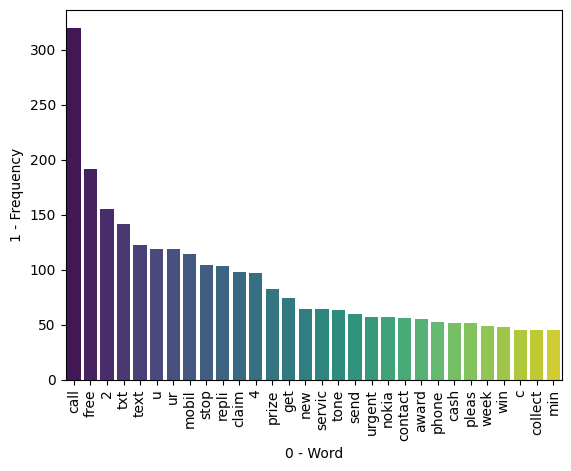

In [43]:
common_word = pd.DataFrame(Counter(spam_Most_freq_word).most_common(30))
sns.barplot(x=common_word[0],y=common_word[1],palette="viridis")
plt.xticks(rotation='vertical')
plt.xlabel("0 - Word")
plt.ylabel("1 - Frequency")
plt.show()

In [44]:
#30 Most frequent words in ham

ham_Most_freq_word = []
for msg in df[df['target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        ham_Most_freq_word.append(word)
print(len(spam_Most_freq_word))
print('---------------------- words-------------------------')
Counter(ham_Most_freq_word).most_common(30)

9939
---------------------- words-------------------------


[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [45]:
pd.DataFrame(Counter(ham_Most_freq_word).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


C:\Users\saroj\AppData\Local\Temp\ipykernel_23680\2171960667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ham_common_word[0],y=ham_common_word[1],palette="viridis")


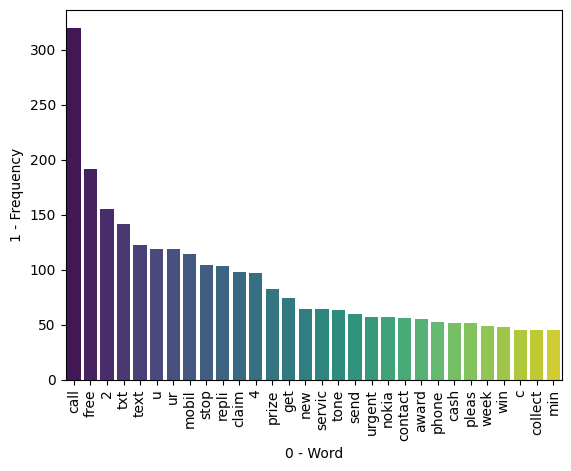

In [46]:
ham_common_word = pd.DataFrame(Counter(ham_Most_freq_word).most_common(30))
sns.barplot(x=ham_common_word[0],y=ham_common_word[1],palette="viridis")
plt.xticks(rotation='vertical')
plt.xlabel("0 - Word")
plt.ylabel("1 - Frequency")
plt.show()

# Modelling

In [47]:
# Bag Of Words -> CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
x = cv.fit_transform(df['transform_text']).toarray() 

In [48]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [49]:
x.shape

(5169, 6708)

In [50]:
y = df['target'].values

In [51]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
x_train, x_test , y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [54]:
from sklearn.naive_bayes import *
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [55]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [56]:
gnb.fit(x_train, y_train)


GaussianNB()

In [57]:
mnb.fit(x_train, y_train)


MultinomialNB()

In [58]:
bnb.fit(x_train, y_train)

BernoulliNB()

In [59]:
Y_pred_gnb = gnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_gnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_gnb))
print("precision_score : ",precision_score(y_test,Y_pred_gnb))

Accuracy_score :  0.8800773694390716
onfusion_matrix :  [[792 104]
 [ 20 118]]
precision_score :  0.5315315315315315


In [60]:
Y_pred_mnb = mnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_mnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_mnb))
print("precision_score : ",precision_score(y_test,Y_pred_mnb))

Accuracy_score :  0.9642166344294004
onfusion_matrix :  [[871  25]
 [ 12 126]]
precision_score :  0.8344370860927153


In [61]:
Y_pred_bnb = bnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_bnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_bnb))
print("precision_score : ",precision_score(y_test,Y_pred_bnb))

Accuracy_score :  0.9700193423597679
onfusion_matrix :  [[893   3]
 [ 28 110]]
precision_score :  0.9734513274336283


# Same modle with TfidVectorizer

In [62]:
# TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import *
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
tfid = TfidfVectorizer()
x = tfid.fit_transform(df['transform_text']).toarray() 

In [63]:
y = df['target'].values
x_train, x_test , y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=2)
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb.fit(x_train, y_train)
mnb.fit(x_train, y_train)
bnb.fit(x_train, y_train)

BernoulliNB()

In [64]:
Y_pred_gnb = gnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_gnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_gnb))
print("precision_score : ",precision_score(y_test,Y_pred_gnb))

Accuracy_score :  0.8762088974854932
onfusion_matrix :  [[793 103]
 [ 25 113]]
precision_score :  0.5231481481481481


In [65]:
Y_pred_mnb = mnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_mnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_mnb))
print("precision_score : ",precision_score(y_test,Y_pred_mnb))

Accuracy_score :  0.9593810444874274
onfusion_matrix :  [[896   0]
 [ 42  96]]
precision_score :  1.0


In [66]:
Y_pred_bnb = bnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_bnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_bnb))
print("precision_score : ",precision_score(y_test,Y_pred_bnb))

Accuracy_score :  0.9700193423597679
onfusion_matrix :  [[893   3]
 [ 28 110]]
precision_score :  0.9734513274336283


# Trying to improve model

In [67]:
tfid1 = TfidfVectorizer(max_features=3000) # here we specified the feature number for vectorization
x = tfid1.fit_transform(df['transform_text']).toarray()
y = df['target'].values
x_train, x_test , y_train , y_test = train_test_split(x,y, test_size=0.2, random_state=2)
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb.fit(x_train, y_train)
mnb.fit(x_train, y_train)
bnb.fit(x_train, y_train)
Y_pred_gnb = gnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_gnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_gnb))
print("precision_score : ",precision_score(y_test,Y_pred_gnb))
print("-----------------------------MNB----------------------------") # here we are getting improvement in Accuracy and we have precision is 1
Y_pred_mnb = mnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_mnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_mnb))
print("precision_score : ",precision_score(y_test,Y_pred_mnb))
print("------------------------------BNB--------------------------------")
Y_pred_bnb = bnb.predict(x_test)
print("Accuracy_score : ",accuracy_score(y_test,Y_pred_bnb))
print("onfusion_matrix : ",confusion_matrix(y_test,Y_pred_bnb))
print("precision_score : ",precision_score(y_test,Y_pred_bnb))

Accuracy_score :  0.8694390715667312
onfusion_matrix :  [[788 108]
 [ 27 111]]
precision_score :  0.5068493150684932
-----------------------------MNB----------------------------
Accuracy_score :  0.9709864603481625
onfusion_matrix :  [[896   0]
 [ 30 108]]
precision_score :  1.0
------------------------------BNB--------------------------------
Accuracy_score :  0.9835589941972921
onfusion_matrix :  [[895   1]
 [ 16 122]]
precision_score :  0.991869918699187


In [68]:
# model deployment

In [69]:
import pickle
pickle.dump(tfid1,open('vectorizer.pk1','wb'))
pickle.dump(mnb,open('model.pk1','wb'))

